# 1. Import & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import sys
from sklearn.impute import SimpleImputer
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
# Versions-Management
print(f"Python: {sys.version}")
print(f"Pandas: {pd.__version__}")

# Warnings kontrollieren
warnings.filterwarnings('ignore', category=FutureWarning)

Python: 3.12.0 (tags/v3.12.0:0fb18b0, Oct  2 2023, 13:03:39) [MSC v.1935 64 bit (AMD64)]
Pandas: 2.3.3


# 2. Daten einlesen

In [2]:
file_path = "../data/Number_of_fires_by_month.csv"
# CSV mit Semikolon-Trenner einlesen
df = pd.read_csv(file_path, sep=";", header=1, encoding="ISO-8859-1")

# 3. Datenbereinigung

In [3]:
# Spaltennamen aufräumen
df.columns = df.columns.str.strip()

# NUR Alberta behalten
df = df[df["Jurisdiction"] == "Alberta"].copy()

# "Data Qualifier"-Spalte entfernen
df = df.loc[:, ~df.columns.str.contains('Data Qualifier', case=False)]

# Alle 'Unspecified'-Einträge in 'Month' löschen
df = df[df["Month"].notna()]
df = df[~df['Month'].str.contains("Unspecified", case=False, na=False)]

# Alle leeren Werte durch NaN ersetzen
df = df.replace(["", " ",], np.nan)

# "Wide" → "Long" Format
df_long = df.melt(
    id_vars=["Jurisdiction", "Month"],  # diese Spalten bleiben fix
    var_name="Year",                    # Name der neuen "Jahr"-Spalte
    value_name="Number_fires"                  # Name für die Werte (z. B. Anzahl Brände)
)

#Month als 1–12 umwandeln
df_long["Month"] = pd.to_datetime(df_long["Month"], format="%B").dt.month

# 4. Explorative Visualisierung

Basisinfo

In [4]:
print(df_long.info())
print(df_long.describe())

# Fehlende Werte je Spalte
print(df_long.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 408 entries, 0 to 407
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Jurisdiction  408 non-null    object 
 1   Month         408 non-null    int32  
 2   Year          408 non-null    object 
 3   Number_fires  385 non-null    float64
dtypes: float64(1), int32(1), object(2)
memory usage: 11.3+ KB
None
            Month  Number_fires
count  408.000000    385.000000
mean     6.500000    111.789610
std      3.456291    135.094835
min      1.000000      1.000000
25%      3.750000      9.000000
50%      6.500000     54.000000
75%      9.250000    175.000000
max     12.000000    658.000000
Jurisdiction     0
Month            0
Year             0
Number_fires    23
dtype: int64


Zeitreihen Visualisierung

Saisonale Muster

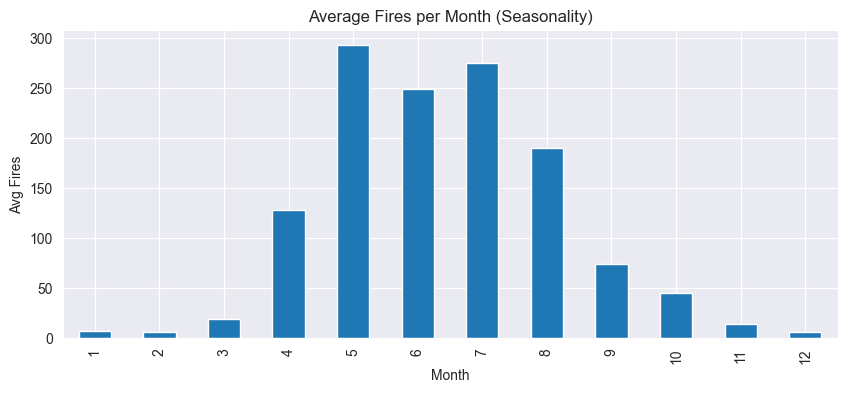

In [5]:
monthly_avg = df_long.groupby("Month")["Number_fires"].mean()

plt.figure(figsize=(10,4))
monthly_avg.plot(kind="bar")
plt.title("Average Fires per Month (Seasonality)")
plt.xlabel("Month")
plt.ylabel("Avg Fires")
plt.show()


<Figure size 1200x500 with 0 Axes>

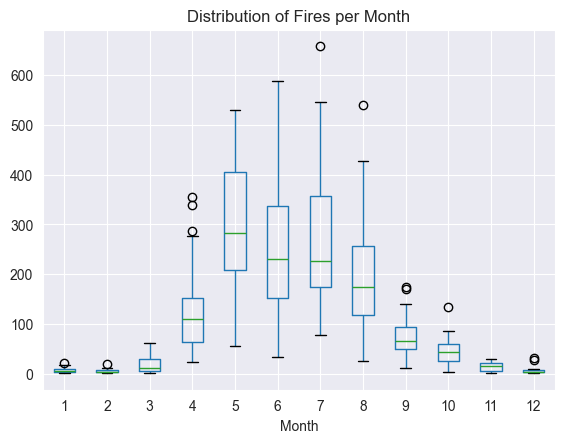

In [6]:
plt.figure(figsize=(12,5))
df_long.boxplot(column="Number_fires", by="Month")
plt.title("Distribution of Fires per Month")
plt.suptitle("")
plt.show()

<Figure size 1200x500 with 0 Axes>

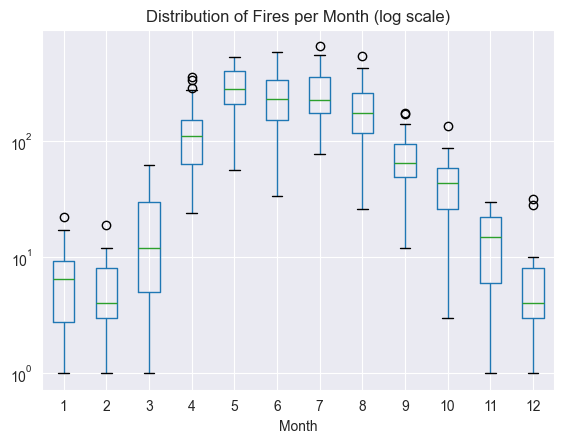

In [7]:
#Log-Skala
plt.figure(figsize=(12,5))
df_long.boxplot(column="Number_fires", by="Month")
plt.yscale("log")
plt.title("Distribution of Fires per Month (log scale)")
plt.suptitle("")
plt.show()

Heatmap Jahr x Monat

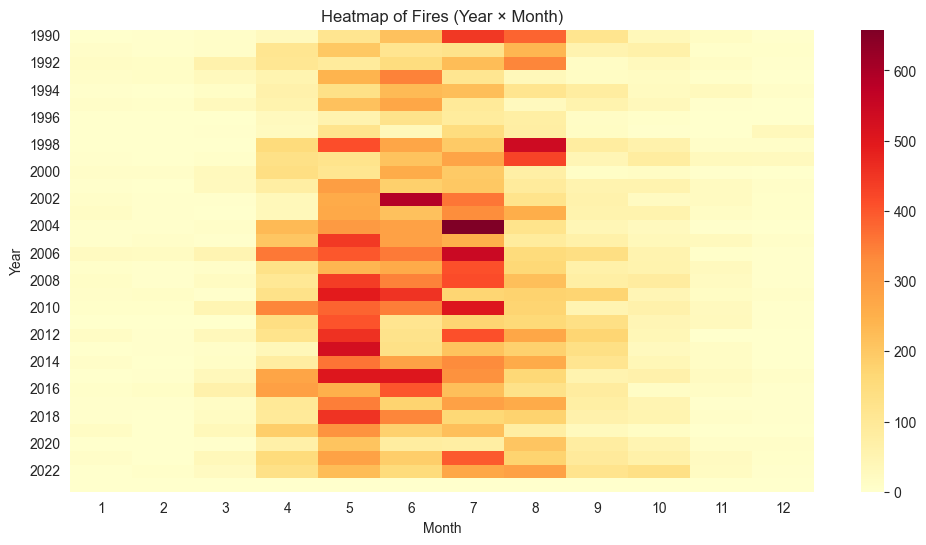

In [8]:
pivot = df_long.pivot_table(
    index="Year",
    columns="Month",
    values="Number_fires",
    aggfunc="sum"
)

plt.figure(figsize=(12,6))
sns.heatmap(pivot, cmap="YlOrRd")
plt.title("Heatmap of Fires (Year × Month)")
plt.show()

Ausreißer identifizieren

<Figure size 1200x600 with 0 Axes>

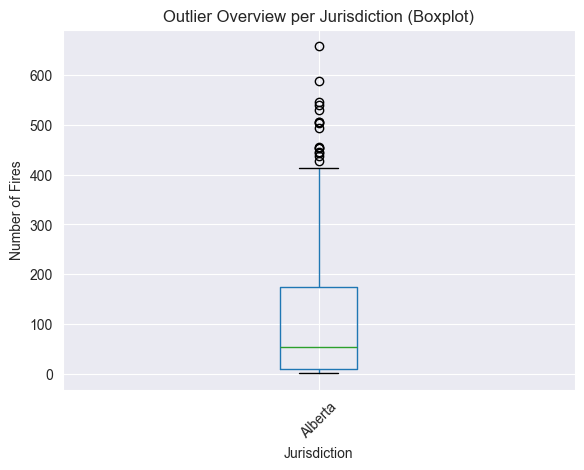

In [10]:
plt.figure(figsize=(12,6))
df_long.boxplot(column="Number_fires", by="Jurisdiction", rot=45)
plt.title("Outlier Overview per Jurisdiction (Boxplot)")
plt.suptitle("")
plt.xlabel("Jurisdiction")
plt.ylabel("Number of Fires")
plt.show()

# 5. Feature Engineering

In [11]:
# Datentypen anpassen
df_long["Year"] = df_long["Year"].astype(int)

# Anzahl (Number_fires) als ganze Zahl
df_long["Number_fires"] = pd.to_numeric(df_long["Number_fires"], errors="coerce").astype("Int64")

df_long = df_long.sort_values(["Year", "Month"])

df_long["Lag_1"] = df_long["Number_fires"].shift(1)
df_long["Lag_2"] = df_long["Number_fires"].shift(2)
df_long["Lag_3"] = df_long["Number_fires"].shift(3)

df_long["RollMean_3"] = (
    df_long["Number_fires"]
    .shift(1)
    .rolling(window=3, min_periods=3)
    .mean()
)
df_long["RollStd_3"] = (
    df_long["Number_fires"]
    .shift(1)
    .rolling(window=3, min_periods=3)
    .std()
)
df_long["RollSum_3"] = (
    df_long["Number_fires"]
    .shift(1)
    .rolling(window=3, min_periods=3)
    .sum()
)

# Saisonale Indikatoren (Regime)
df_long["is_summer"] = df_long["Month"].isin([6, 7, 8]).astype(int)

# Trigonometrisches Encoding für Monat (1–12)
df_long["Month_sin"] = np.sin(2 * np.pi * df_long["Month"] / 12)
df_long["Month_cos"] = np.cos(2 * np.pi * df_long["Month"] / 12)

# Kontrolle
df_long[["Month", "Month_sin", "Month_cos"]].head(12)
df_long[["Number_fires", "Lag_1", "RollMean_3"]].head(15)
print(df_long.head(20))
print(df_long.dtypes)
df_fires = df_long.copy()

   Jurisdiction  Month  Year  Number_fires  Lag_1  Lag_2  Lag_3  RollMean_3  \
0       Alberta      1  1990             1   <NA>   <NA>   <NA>         NaN   
1       Alberta      2  1990             5      1   <NA>   <NA>         NaN   
2       Alberta      3  1990             8      5      1   <NA>         NaN   
3       Alberta      4  1990            26      8      5      1    4.666667   
4       Alberta      5  1990           114     26      8      5   13.000000   
5       Alberta      6  1990           214    114     26      8   49.333333   
6       Alberta      7  1990           446    214    114     26  118.000000   
7       Alberta      8  1990           381    446    214    114  258.000000   
8       Alberta      9  1990           117    381    446    214  347.000000   
9       Alberta     10  1990            34    117    381    446  314.666667   
10      Alberta     11  1990            16     34    117    381  177.333333   
11      Alberta     12  1990             4     16   

# 6. Wetterdaten Bereinigung

In [12]:
# Spalte time löschen und type ändern
df_weather = pd.read_csv(
    "../data/cleaned_Alberta_monthly_mean.csv"
)
if "time" in df_weather.columns:
   df_weather = df_weather.drop(columns=["time"])

df_weather["Year"] = df_weather["Year"].astype(int)
df_weather["Month"] = df_weather["Month"].astype(int)

print(df_weather.shape)
print(df_weather.columns)

(397, 12)
Index(['temperature_2m_mean (°C)', 'temperature_2m_max (°C)',
       'relative_humidity_2m_mean (%)', 'relative_humidity_2m_min (%)',
       'precipitation_sum (mm)', 'precipitation_hours (h)',
       'wind_speed_10m_mean (km/h)', 'wind_speed_10m_max (km/h)',
       'wind_direction_10m_dominant (°)', 'et0_fao_evapotranspiration (mm)',
       'Year', 'Month'],
      dtype='object')


In [13]:
# Spalten löschen aufgrund der Korrel. Analyse (Finale Feature Definition)
cols_to_drop = [
    "precipitation_sum (mm)",
    "precipitation_hours (h)",
    "wind_speed_10m_mean (km/h)",
    "wind_speed_10m_max (km/h)",
    "wind_direction_10m_dominant (°)"
]

df_weather = df_weather.drop(
    columns=[c for c in cols_to_drop if c in df_weather.columns]
)
print(df_weather.columns)
print(df_weather.dtypes)

Index(['temperature_2m_mean (°C)', 'temperature_2m_max (°C)',
       'relative_humidity_2m_mean (%)', 'relative_humidity_2m_min (%)',
       'et0_fao_evapotranspiration (mm)', 'Year', 'Month'],
      dtype='object')
temperature_2m_mean (°C)           float64
temperature_2m_max (°C)            float64
relative_humidity_2m_mean (%)      float64
relative_humidity_2m_min (%)       float64
et0_fao_evapotranspiration (mm)    float64
Year                                 int64
Month                                int64
dtype: object


In [14]:
df_weather_lag = df_weather.sort_values(["Year", "Month"]).copy()
weather_cols = [c for c in df_weather_lag.columns if c not in ["Year", "Month"]]
df_weather_lag[weather_cols] = df_weather_lag[weather_cols].shift(1)

# 6a. Merge Wetterdaten & Anzahl Brände

In [15]:
# Merge
df_merged = pd.merge(
    df_fires,
    df_weather_lag,
    on=["Year", "Month"],
    how="inner"
).dropna().reset_index(drop=True)

print(df_merged.shape)
print(df_merged.isna().sum())
print(df_merged.head())

(354, 18)
Jurisdiction                       0
Month                              0
Year                               0
Number_fires                       0
Lag_1                              0
Lag_2                              0
Lag_3                              0
RollMean_3                         0
RollStd_3                          0
RollSum_3                          0
is_summer                          0
Month_sin                          0
Month_cos                          0
temperature_2m_mean (°C)           0
temperature_2m_max (°C)            0
relative_humidity_2m_mean (%)      0
relative_humidity_2m_min (%)       0
et0_fao_evapotranspiration (mm)    0
dtype: int64
  Jurisdiction  Month  Year  Number_fires  Lag_1  Lag_2  Lag_3  RollMean_3  \
0      Alberta      4  1990            26      8      5      1    4.666667   
1      Alberta      5  1990           114     26      8      5   13.000000   
2      Alberta      6  1990           214    114     26      8   49.333333   

# 7. Feature Engineering Wetterdaten + Vorbereitung für den Split

In [16]:
df_merged = df_merged.sort_values(["Year", "Month"])

weather_features = [
    "temperature_2m_mean (°C)",
    "relative_humidity_2m_mean (%)",
    "relative_humidity_2m_min (%)",
    "et0_fao_evapotranspiration (mm)",
    "temperature_2m_max (°C)"
]

for col in weather_features:
    df_merged[f"{col}_lag1"] = df_merged[col].shift(1)

# Zeitgleiche Wetterdaten entfernen
df_merged = df_merged.drop(columns=weather_features)

# NaNs durch Lag entfernen
df_merged = df_merged.dropna().reset_index(drop=True)

In [17]:
# Number of fires als Zielvariabel setzen und NaNs in Number of fires löschen
target = "Number_fires"
df_model = df_merged[df_merged[target].notna()].copy()
df_model.to_csv("../data/final_data_v4_alberta.csv", index=False)

In [18]:
target = "Number_fires"

X = df_model.drop(columns=[target])
y = df_model[target]

# 8. Train/ Test Split

In [20]:
# Training: ca. 60% der Zeit (1990–2012), Validation: ca. 20 % (2013–2017), Test: ca. 20 % (2018–2023)

mask_train = df_model["Year"] <= 2012
mask_val   = (df_model["Year"] > 2012) & (df_model["Year"] <= 2017)
mask_test  = df_model["Year"] > 2017

# Feature-Liste (Year explizit entfernen!)
feature_cols = [
    c for c in df_model.columns
    if c not in [target, "Year"]
]

X = df_model[feature_cols]
y = df_model[target]

# Zeitbasierter Split
X_train = X.loc[mask_train].copy()
y_train = y.loc[mask_train].copy()

X_val = X.loc[mask_val].copy()
y_val = y.loc[mask_val].copy()

X_test = X.loc[mask_test].copy()
y_test = y.loc[mask_test].copy()

# Imputation (nur numerische Features)
num_cols = X_train.select_dtypes(include=["number"]).columns

imputer = SimpleImputer(strategy="median")

X_train.loc[:, num_cols] = imputer.fit_transform(X_train.loc[:, num_cols])
X_val.loc[:, num_cols]   = imputer.transform(X_val.loc[:, num_cols])
X_test.loc[:, num_cols]  = imputer.transform(X_test.loc[:, num_cols])

# Imputer für Backend speichern
joblib.dump(imputer, "../backend/imputer_alberta.joblib")
print("IMPUTER GESPEICHERT")

# Konsistenz-Checks
print("Train max year:", df_model.loc[mask_train, "Year"].max())
print("Test min year:", df_model.loc[mask_test, "Year"].min())

assert target not in X_train.columns
assert len(X_train) == len(y_train)
assert X_train.isna().sum().sum() == 0
assert X_val.isna().sum().sum() == 0
assert X_test.isna().sum().sum() == 0

IMPUTER GESPEICHERT
Train max year: 2012
Test min year: 2018


In [21]:
# Jurisdiction entfernen
X_train = X_train.drop(columns=["Jurisdiction"])
X_val   = X_val.drop(columns=["Jurisdiction"])
X_test  = X_test.drop(columns=["Jurisdiction"])

# 9. Baseline trainieren - Random Forest

In [22]:
#Random-Forest-Baseline definieren
rf_baseline = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

In [23]:
#Modell trainieren
rf_baseline.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [24]:
#Vorhersage trainieren
y_pred_train = rf_baseline.predict(X_train)
y_pred_val   = rf_baseline.predict(X_val)
y_pred_test  = rf_baseline.predict(X_test)

# 10. Baseline Modell evaluieren - Random Forest

In [25]:
def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"{name} → MAE: {mae:.2f}, RMSE: {rmse:.2f}")

evaluate(y_train, y_pred_train, "Train")
evaluate(y_val,   y_pred_val,   "Validation")
evaluate(y_test,  y_pred_test,  "Test")


Train → MAE: 18.98, RMSE: 32.28
Validation → MAE: 46.50, RMSE: 76.28
Test → MAE: 39.08, RMSE: 61.67


# 9a Baseline trainieren - XGBoost

In [26]:
# Baseline definieren MIT Early Stopping
xgb_baseline = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    min_child_weight=5,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=1.0,
    reg_lambda=2.0,
    early_stopping_rounds=20,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

# Baseline Modell trainieren (MIT eval_set!)
xgb_baseline.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.7
,device,None
,early_stopping_rounds,20
,enable_categorical,False
,eval_metric,None


In [27]:
#Vorhersagen erzeugen
y_pred_train_xgb = xgb_baseline.predict(X_train)
y_pred_val_xgb   = xgb_baseline.predict(X_val)
y_pred_test_xgb  = xgb_baseline.predict(X_test)

# 10a Baseline evaluieren - XG Boost

In [28]:
def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"{name} → MAE: {mae:.2f}, RMSE: {rmse:.2f}")

evaluate(y_train, y_pred_train_xgb, "Train")
evaluate(y_val,   y_pred_val_xgb,   "Validation")
evaluate(y_test,  y_pred_test_xgb,  "Test")


Train → MAE: 27.81, RMSE: 45.91
Validation → MAE: 47.21, RMSE: 73.80
Test → MAE: 38.27, RMSE: 60.90


In [29]:
# Fehleranalyse – Single-Region-Modell (Alberta)

test_errors = pd.DataFrame({
    "actual": y_test.values,
    "predicted": y_pred_test_xgb,
    "error": np.abs(y_test.values - y_pred_test_xgb),
    "Year": df_model.loc[y_test.index, "Year"].values
})

print("\nGrößte Fehler:")
print(
    test_errors
    .nlargest(10, "error")[["actual", "predicted", "error", "Year"]]
)

print("\nFehler-Statistiken:")
print(f"Median Error: {test_errors['error'].median():.2f}")
print(f"90th Percentile Error: {test_errors['error'].quantile(0.9):.2f}")



Größte Fehler:
    actual   predicted       error  Year
25      83  351.945251  268.945251  2020
27     208   84.248108  123.751892  2020
15      78  197.608200    119.6082  2019
26      78  184.713821  106.713821  2020
23      68  172.143311  104.143311  2020
49     153  250.773865   97.773865  2022
38     396  300.823029   95.176971  2021
53     135   51.577763   83.422237  2022
14     219  300.416077   81.416077  2019
1      337  258.382538   78.617462  2018

Fehler-Statistiken:
Median Error: 13.27
90th Percentile Error: 96.48


# 11. Modellauswahl

Obwohl der Random-Forest-Regressor als Baseline-Modell eine vergleichsweise gute Trainingsleistung erzielte, zeigte er eine ausgeprägte Überanpassung und eine eingeschränkte Generalisierungsfähigkeit. Aufgrund dieser strukturellen Limitationen wurde Random Forest nicht weiter optimiert, sondern durch leistungsfähigere Boosting-Modelle ersetzt.

# 12. Optimierung

In [30]:
#Hyperparameter Tuning
configs = {
    "baseline": {
        "max_depth": 6,
        "learning_rate": 0.05,
        "min_child_weight": 1
    },
    "regularized_depth5": {
        "max_depth": 5,
        "learning_rate": 0.05,
        "min_child_weight": 3
    },
    "regularized_depth4": {
        "max_depth": 4,
        "learning_rate": 0.03,
        "min_child_weight": 5
    }
}


In [31]:
#Evaluation
results = []

for name, cfg in configs.items():
    model = XGBRegressor(
        n_estimators=400,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1,
        **cfg
    )

    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    y_val_pred = model.predict(X_val)

    mae = mean_absolute_error(y_val, y_val_pred)
    rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))

    results.append((name, mae, rmse))

    print(f"{name} → Val MAE: {mae:.2f}, Val RMSE: {rmse:.2f}")


baseline → Val MAE: 51.28, Val RMSE: 78.44
regularized_depth5 → Val MAE: 51.45, Val RMSE: 78.87
regularized_depth4 → Val MAE: 51.15, Val RMSE: 78.27


# 13. Training & Evaluation

In [32]:
# Train + Validation zusammenführen
X_final = pd.concat([X_train, X_val])
y_final = pd.concat([y_train, y_val])

final_model = XGBRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=5,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=1.0,
    reg_lambda=2.0,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

final_model.fit(X_final, y_final)

y_test_pred = final_model.predict(X_test)

In [33]:
mae_test = mean_absolute_error(y_test, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

print(f"Final Model – Test MAE:  {mae_test:.2f}")
print(f"Final Model – Test RMSE: {rmse_test:.2f}")

Final Model – Test MAE:  42.33
Final Model – Test RMSE: 68.35


# 14. Interpretation & Ergebnisse

In [34]:
#Feature Importance
importance = final_model.get_booster().get_score(importance_type="gain")

# In DataFrame umwandeln
imp_df = (
    pd.DataFrame(importance.items(), columns=["Feature", "Gain"])
    .sort_values(by="Gain", ascending=False)
)
print(imp_df.head(15))

                                 Feature          Gain
9                              Month_cos  88897.468750
7                              is_summer  28624.701172
1                                  Lag_1   7975.060547
12     relative_humidity_2m_min (%)_lag1   5841.227051
14          temperature_2m_max (°C)_lag1   5796.331055
5                              RollStd_3   5130.416504
10         temperature_2m_mean (°C)_lag1   4223.470215
13  et0_fao_evapotranspiration (mm)_lag1   3789.980469
0                                  Month   3788.953369
11    relative_humidity_2m_mean (%)_lag1   3632.316895
4                             RollMean_3   3552.088135
3                                  Lag_3   3499.126465
2                                  Lag_2   3257.291260
6                              RollSum_3   2918.588379
8                              Month_sin   1021.378357


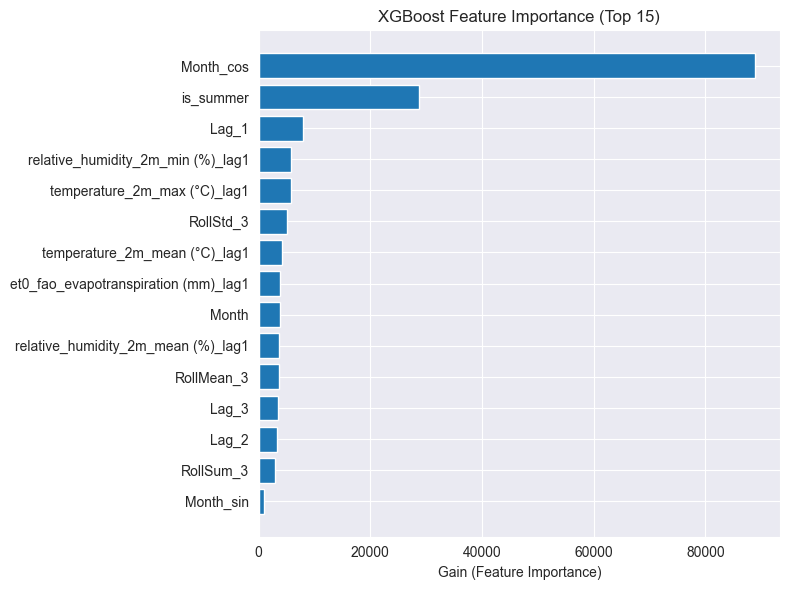

In [35]:
top_n = 15
plt.figure(figsize=(8, 6))
plt.barh(
    imp_df["Feature"].head(top_n)[::-1],
    imp_df["Gain"].head(top_n)[::-1]
)
plt.xlabel("Gain (Feature Importance)")
plt.title("XGBoost Feature Importance (Top 15)")
plt.tight_layout()
plt.show()


In [36]:
# Vorhersagen
y_test_pred = final_model.predict(X_test)

# Fehleranalyse-DataFrame
df_errors = pd.DataFrame({
    "y_true": y_test.values,
    "y_pred": y_test_pred
}, index=y_test.index)

df_errors["error"] = df_errors["y_true"] - df_errors["y_pred"]
df_errors["abs_error"] = np.abs(df_errors["error"])

# Zeitinformation aus df_model ergänzen (nicht aus X!)
df_errors["Year"] = df_model.loc[df_errors.index, "Year"]
df_errors["Month"] = df_model.loc[df_errors.index, "Month"]

# Nach Zeit sortieren (wichtig!)
df_errors = df_errors.sort_values(["Year", "Month"]).reset_index(drop=True)


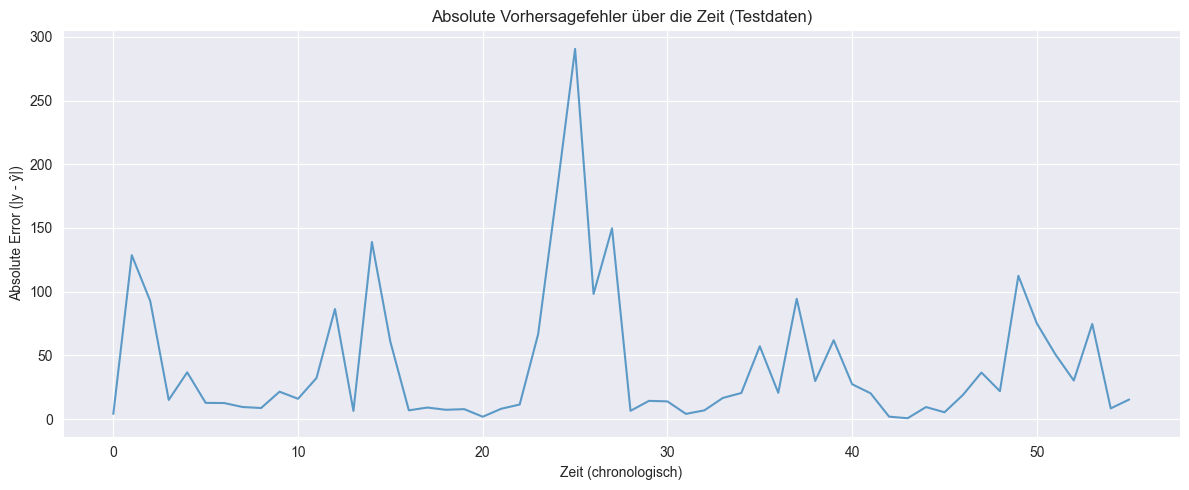

In [37]:
# Fehler über die Zeit visualisieren
plt.figure(figsize=(12, 5))
plt.plot(
    range(len(df_errors)),
    df_errors["abs_error"],
    label="Absolute Error",
    alpha=0.7
)
plt.ylabel("Absolute Error (|y - ŷ|)")
plt.xlabel("Zeit (chronologisch)")
plt.title("Absolute Vorhersagefehler über die Zeit (Testdaten)")
plt.tight_layout()
plt.show()

In [38]:
#Fehler nach Jahreszeit analysieren (Sommer vs. Rest)
def season_from_month(m):
    if m in [12, 1, 2]:
        return "Winter"
    elif m in [3, 4, 5]:
        return "Spring"
    elif m in [6, 7, 8]:
        return "Summer"
    else:
        return "Fall"

df_errors["Season"] = df_errors["Month"].apply(season_from_month)

In [39]:
season_error = (
    df_errors
    .groupby("Season")["abs_error"]
    .mean()
    .sort_values(ascending=False)
)

print(season_error)

Season
Summer    93.660919
Spring    47.043163
Fall      18.802493
Winter     8.507952
Name: abs_error, dtype: Float64


In [40]:
#Analyse der Extremmonate (wo schwächelt das Modell?)
df_errors.nlargest(10, "abs_error")[
    ["Year", "Month", "y_true", "y_pred", "abs_error"]
]


,Year,Month,y_true,y_pred,abs_error
25,2020,6,83,373.583984,290.583984
24,2020,5,209,385.718506,176.718506
27,2020,8,208,58.260704,149.739296
14,2019,7,219,357.933350,138.93335
1,2018,6,337,208.388168,128.611832
49,2022,6,153,265.453644,112.453644
26,2020,7,78,176.196762,98.196762
37,2021,6,189,283.384186,94.384186
2,2018,7,166,258.550934,92.550934
12,2019,5,315,228.646103,86.353897


# 15. Export der Modelle/Plots

In [41]:
model_path = "../models/xgboost_final_model_v4_alberta.joblib"
joblib.dump(final_model, model_path)

print("Modell erfolgreich gespeichert:", model_path)

Modell erfolgreich gespeichert: ../models/xgboost_final_model_v4_alberta.joblib


In [42]:
#feature namen seperat speichern
feature_path = "../models/xgboost_features_v4_alberta.joblib"
joblib.dump(list(X_final.columns), feature_path)

print("Feature-Liste gespeichert.")

Feature-Liste gespeichert.
